In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
N = 300

def rhs(t, F, params):
    """
    Right-hand side for the system F0..F8.
    F is ordered [F0, F1, F2, F3, F4, F5, F6, F7, F8].
    params is a dict containing: k_avg, lam1, lam2, mu, mu_bar
    """
    k = params['k_avg']
    lam1 = params['lam1']
    lam2 = params['lam2']
    mu = params['mu']
    mu_bar = params['mu_bar']
    
    F0, F1, F2, F3, F4, F5, F6, F7, F8 = F

    # common combinations
    comb1 = F1 + F4 + F7
    comb2 = F3 + F4 + F5

    dF0 = -k * lam1 * F0 * comb1 - k * lam2 * F0 * comb2
    dF1 = -F1 * mu - k * lam2 * F1 * comb2 + k * lam1 * F0 * comb1
    dF2 = F1 * mu - k * F2 * lam2 * comb2
    dF3 = -k * lam1 * F3 * comb1 - F3 * mu + k * lam2 * F0 * comb2
    dF4 = k * lam1 * F3 * comb1 + k * lam2 * F1 * comb2 - F4 * mu_bar
    dF5 = k * lam2 * F2 * comb2 - F5 * mu
    dF6 = -k * lam1 * F6 * comb1 + F3 * mu
    dF7 = k * lam1 * F6 * comb1 - F7 * mu
    dF8 = F4 * mu_bar + F7 * mu + F5 * mu

    return [dF0, dF1, dF2, dF3, dF4, dF5, dF6, dF7, dF8]

#Initial conditions
# Order: F0, F1, F2, F3, F4, F5, F6, F7, F8
y0 = [(N-2)/N, 1/N, 0, 1/N, 0, 0, 0, 0, 0]  

# --- Time span and evaluation times ---
t_span = (0.0, 15.0)               # start and end time
t_eval = np.linspace(t_span[0], t_span[1], 501)



In [3]:
mu_bar_range = np.linspace(.5, 1.5, 200)

Lrange = np.linspace(0.5, 1.5, 200)

peaks = []

for L in Lrange:
    peak = []
    for m in mu_bar_range:
        params = {
            'k_avg': 10,    # <k>
            'lam1': L,     # lambda_1
            'lam2': 1,     # lambda_2
            'mu': 1.0,       # mu
            'mu_bar': m    # \bar{\mu}
            }

        sol = solve_ivp(lambda t, y: rhs(t, y, params),
                    t_span, y0, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)
    
        i_A = sol.y[1] + sol.y[4] + sol.y[7]
        i_B = sol.y[3] + sol.y[4] + sol.y[5]
        J = i_A + i_B - sol.y[4]
        
        peak.append(max(J))
    peaks.append(peak)        

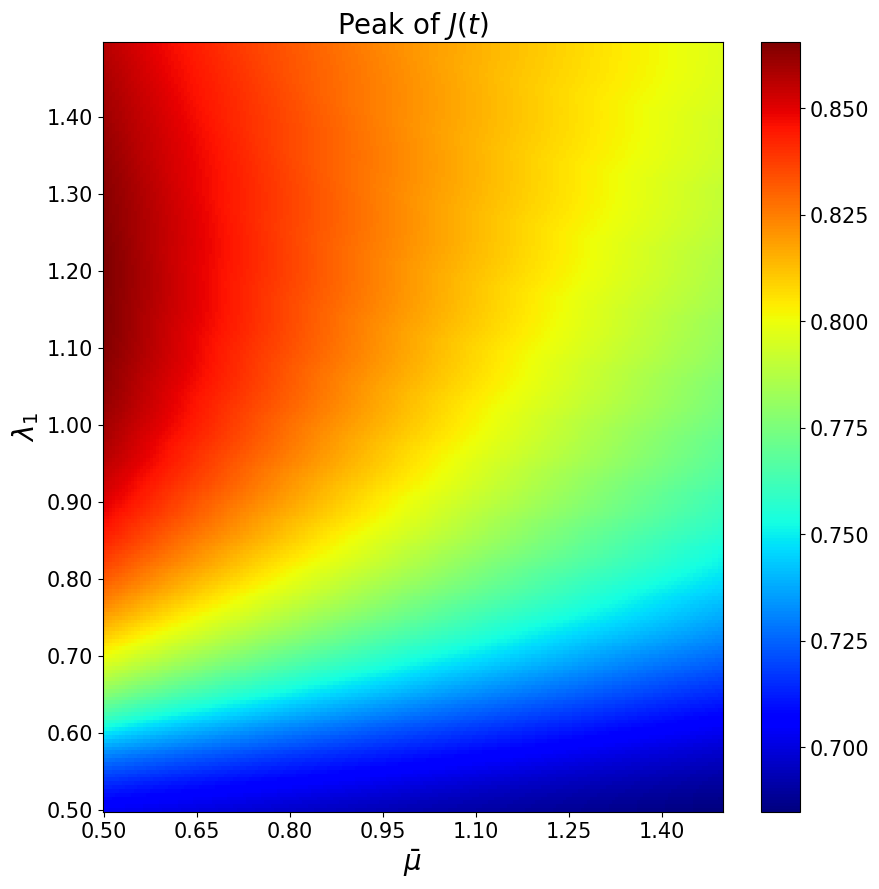

In [4]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111) 
ax.imshow(peaks, cmap='jet', aspect='auto', origin='lower')
cbar = plt.colorbar(ax.images[0])  # need to reference the image for colorbar
ax.set_xlabel(r"$\bar{\mu}$", fontsize=20)
ax.set_ylabel(r"$\lambda_1$", fontsize=20)

n = 20

ax.set_xticks(range(0, len(mu_bar_range), n+10))
ax.set_xticklabels([f'{x:.2f}' for x in mu_bar_range[::n+10]], fontsize=15)

ax.set_yticks(range(0, len(Lrange), n))
ax.set_yticklabels([f'{x:.2f}' for x in Lrange[::n]], fontsize=15)

ax.set_title("Peak of $J(t)$", fontsize=20)
cbar.ax.tick_params(labelsize=15)
plt.show()